In [30]:
import pandas as pd

In [62]:
df = pd.read_csv('zim_schools.csv')

In [63]:
df.shape

(15, 10)

In [64]:
df.dtypes

School             str
District           str
Province           str
Students         int64
Pass_Rate        int64
Math_Score       int64
English_Score    int64
Science_Score    int64
Teachers         int64
Budget_USD       int64
dtype: object

In [65]:
df.isnull().sum()

School           0
District         0
Province         0
Students         0
Pass_Rate        0
Math_Score       0
English_Score    0
Science_Score    0
Teachers         0
Budget_USD       0
dtype: int64

In [66]:
df = df.assign(Average_Score = df[['Math_Score','English_Score','Science_Score']].mean(axis=1)).round(2)
df.insert(8, 'Average_Score', df.pop('Average_Score'))

In [67]:
df

,School,District,Province,Students,Pass_Rate,Math_Score,English_Score,Science_Score,Average_Score,Teachers,Budget_USD
0,Harare High,Harare,Harare,450,78,65,72,68,68.33,22,45000
1,Churchill Boys,Harare,Harare,380,92,88,85,90,87.67,25,62000
2,Mabelreign Girls,Harare,Harare,320,85,80,88,79,82.33,18,38000
3,Marist Brothers,Bulawayo,Matabeleland,410,71,60,68,65,64.33,20,41000
4,Mpopoma High,Bulawayo,Matabeleland,290,65,55,62,58,58.33,15,30000
5,Fatima High,Bulawayo,Matabeleland,350,88,82,86,84,84.00,21,48000
6,Mutare Boys,Mutare,Manicaland,300,75,70,73,71,71.33,17,35000
7,Dangamvura High,Mutare,Manicaland,275,60,52,58,55,55.00,14,28000
8,St Augustine,Mutare,Manicaland,200,90,87,91,88,88.67,16,40000
9,Gweru High,Gweru,Midlands,330,68,61,65,62,62.67,16,32000


In [81]:
top_schools = df[['School','Pass_Rate']].sort_values(by='Pass_Rate', ascending=False)
top_schools.head(3)

,School,Pass_Rate
14,Prince Edward,95
1,Churchill Boys,92
8,St Augustine,90


In [82]:
top_province = (df.groupby('Province')['Pass_Rate']
                  .mean().round(2).reset_index().sort_values(by='Pass_Rate', ascending=False)
               )
top_province.head(1)

,Province,Pass_Rate
0,Harare,87.5


In [83]:
corr_PassBudget = df['Pass_Rate'].corr(df['Budget_USD'], method='pearson')
corr_PassBudget 

np.float64(0.8245729356349623)

In [84]:
flaged_schools = top_schools[top_schools['Pass_Rate'] < 70 ]
flaged_schools

,School,Pass_Rate
9,Gweru High,68
4,Mpopoma High,65
13,Zvishavane High,63
7,Dangamvura High,60


In [90]:
df['Teacher_Student_Ratio'] = (df['Students']/df['Teachers']).round(2)
teacher_student = df[['School','Teacher_Student_Ratio']].sort_values(by='Teacher_Student_Ratio', ascending=False)
teacher_student

,School,Teacher_Student_Ratio
9,Gweru High,20.62
3,Marist Brothers,20.50
0,Harare High,20.45
7,Dangamvura High,19.64
12,Chinhoyi High,19.38
4,Mpopoma High,19.33
13,Zvishavane High,18.46
2,Mabelreign Girls,17.78
6,Mutare Boys,17.65
11,Mkoba High,17.33


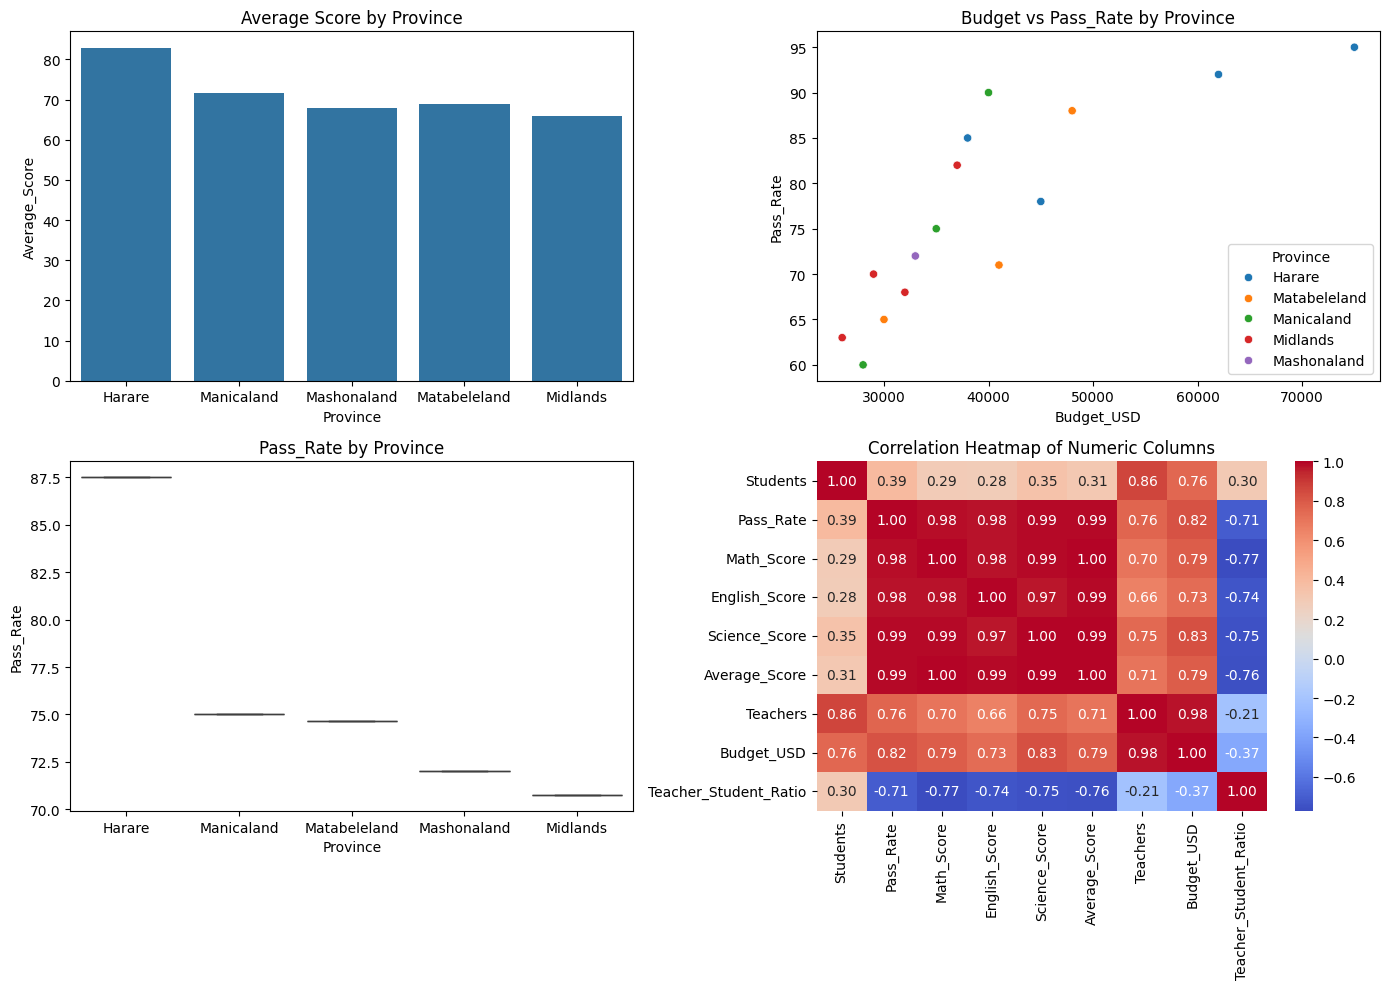

In [103]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

province_avg = df.groupby('Province')['Average_Score'].mean().round(2).reset_index()
sns.barplot(data=province_avg, x='Province', y = 'Average_Score', ax=axes[0, 0])
axes[0, 0].set_title('Average Score by Province')

sns.scatterplot(data=df, x='Budget_USD', y='Pass_Rate', hue='Province', ax=axes[0, 1])
axes[0, 1].set_title('Budget vs Pass_Rate by Province')

sns.boxplot(data=top_province, x='Province', y = 'Pass_Rate', ax=axes[1, 0])
axes[1, 0].set_title('Pass_Rate by Province')

numeric_df = df.select_dtypes(include='number')
relation = numeric_df.corr(method='pearson')
sns.heatmap(relation, annot=True, cmap='coolwarm', fmt='.2f', ax=axes[1, 1])
ax=axes[1, 1].set_title("Correlation Heatmap of Numeric Columns")

plt.tight_layout()
plt.show()

In [102]:
def generate_report(df, top_schools, flaged_schools,corr_PassBudget, teacher_student):
    
    
    overall = pd.DataFrame([
        {"Metric": "Average Pass_Rate", "Result": df['Pass_Rate'].mean().round(2)},
        {"Metric": "Top province", "Result": df.groupby('Province')['Pass_Rate'].mean().idxmax()},
        {"Metric": "Average Score", "Result": df['Average_Score'].mean().round(2)},
        {"Metric": "Budget vs Pass_Rate Correlation", "Result": f'{corr_PassBudget: .2f}'},
         {"Metric": "Average Teacher-Student Ratio", "Result":teacher_student['Teacher_Student_Ratio'].mean().round()}
        
    ])

    
    top_3 = top_schools.head(3).copy()
    top_3.columns = ['Metric', 'Result']

    flaged = flaged_schools.copy()
    flaged.columns = ['Metric', 'Result']

    
    
    report = pd.concat([overall, 
                        pd.DataFrame([{"Metric": "---TOP 3 SCHOOLS BY PASS RATE---", "Result": ""}]),
                        top_3,
                        pd.DataFrame([{"Metric": "---SCHOOLS WITH LEAST PASS RATE---", "Result": ""}]),
                        flaged
                        ], ignore_index=True)
    
    report.to_csv("zimsec_report.csv", index=False)
    return report

generate_report(df, top_schools, flaged_schools,corr_PassBudget, teacher_student)

,Metric,Result
0,Average Pass_Rate,76.93
1,Top province,Harare
2,Average Score,72.31
3,Budget vs Pass_Rate Correlation,0.82
4,Average Teacher-Student Ratio,18.0
5,---TOP 3 SCHOOLS BY PASS RATE---,
6,Prince Edward,95
7,Churchill Boys,92
8,St Augustine,90
9,---SCHOOLS WITH LEAST PASS RATE---,
